In [11]:
import config_paths_ipynb

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import glycowork.glycan_data.stats as glwstats

from sklearn.preprocessing import FunctionTransformer

from ibd_biom_glycoda.config import DATASETS_DIR, FIGURE_DIR
from ibd_biom_glycoda.utils import seed_everything
from ibd_biom_glycoda.data.dataset import load_dataset_excel, prepare_ibd_dataset
from ibd_biom_glycoda.data.transformations import CLRProcessor, GlyCompareProcessor
from ibd_biom_glycoda.analysis.pipelines import make_estimators, make_preprocessors
from ibd_biom_glycoda.analysis.loco_cv import run_loco_cv, aggregate_loco_results_per_test_cohort, summarize_loco_results_all
from ibd_biom_glycoda.evaluation.domain_generalization import run_full_generalization_gap_analysis_overall, plot_generalization_gaps_overall, plot_between_test_cohort_metrics_overall
from ibd_biom_glycoda.evaluation.subgroup_analysis import run_full_generalization_gap_analysis_subgroups, plot_generalization_gaps_subgroups, plot_between_test_cohort_metrics_subgroup, generate_strata_summary
from ibd_biom_glycoda.plotting.style import rcparams_aga, create_figure_with_panels, save_figure_aga_compliant, generate_semantic_colors

# Seed everything
SEED = 42
seed_everything(SEED)
# Override glycowork RNG
glwstats.rng = np.random.default_rng(SEED)

# Load and preprocess data
fname = 'ibd_biom_prospective_dataset_baseline.xlsx'
df_ibd = load_dataset_excel(fname, data_dir=DATASETS_DIR)

# Specify dataset
BINARY = True
FULL_STRATIFICATION = True
SAMPLE_WEIGHTS = True
INCLUDE_COVARIATES = True

df_binary, coda_cols = prepare_ibd_dataset(df_ibd, binary=BINARY)

print(f"\nNumber of samples in the full dataset: {len(df_binary)}")
print(f"Number of CODA features: {len(coda_cols)}")
print(f"Disease distribution:\n{df_binary['DISEASE'].value_counts()}")

# Define test cohorts
LOCO_TEST_COHORTS = ['UK', 'US', 'IT', 'NL']

# Specify the number of randomization runs
seeds = [0, 17, 42, 1000, 1997, 2025, 10000, 20250, 50000, 99999]
num_runs = 5  # You can set this from 1 to len(seeds)
selected_seeds = seeds[:num_runs]

# Specify the number of folds for inner cross-validation
K = 5

# Specify model hyperparameters
PARAMETERS_LR = {
    'C': 0.1,
    'penalty': 'l2',
    'class_weight': 'balanced',
    'solver': 'saga',
    'max_iter': 1000,
    'multi_class': 'multinomial'
}

PARAMETERS_XB = {
    'n_estimators': 50,
    'learning_rate': 0.05,
    'max_depth': 2,
    'objective': 'multi:softprob' if not BINARY else 'binary:logistic',
    'eval_metric': 'mlogloss' if not BINARY else 'logloss',
    'early_stopping_rounds': 5,
}

PARAMETERS_ALL = {
    'LR': PARAMETERS_LR,
    'XB': PARAMETERS_XB,
}

PALETTE = 'okabe_ito'
rcparams_aga(palette=PALETTE)
DISEASE_COLORS, COHORT_COLORS, METRICS_COLORS, SUBGROUP_COLORS, PROCESSOR_COLORS, MODEL_COLORS = generate_semantic_colors(palette=PALETTE, preview=False)

Dropped 0 low abundant GP columns: []
Retained 24 GP columns: ['GP1_FA1', 'GP2_A2', 'GP3_A2B', 'GP4_FA2', 'GP5_M5', 'GP6_FA2B', 'GP7_A2G1', 'GP8_FA2_6_G1', 'GP9_FA2_3_G1', 'GP10_FA2_6_BG1', 'GP11_FA2_3_BG1', 'GP12_A2G2', 'GP13_A2BG2', 'GP14_FA2G2', 'GP15_FA2BG2', 'GP16_FA2G1S1', 'GP17_A2G2S1', 'GP18_FA2G2S1', 'GP19_FA2BG2S1', 'GP20__', 'GP21_A2G2S2', 'GP22_A2BG2S2', 'GP23_FA2G2S2', 'GP24_FA2BG2S2']

Number of samples in the full dataset: 1367
Number of CODA features: 24
Disease distribution:
DISEASE
Control    731
Case       636
Name: count, dtype: int64


In [12]:
# Define estimators
MODEL_KEYS = ['LR', 'XB']
all_estimators = make_estimators(PARAMETERS_ALL, seeds[0])  
estimators     = { k: all_estimators[k] for k in MODEL_KEYS }

# Define preprocessors
processors = {
    'Raw': FunctionTransformer(lambda X: X.values if hasattr(X, "values") else X, validate=False),
    'CLR': CLRProcessor(gamma=0.1, seed=seeds[0]),
    'GlyCmp': GlyCompareProcessor(orig_df=df_binary, coda_cols=coda_cols, abd_fname='glycomotif_abd_df.xlsx', annot_fname='glycomotif_annot_df.xlsx', data_dir=DATASETS_DIR),

}
PROCESSOR_KEYS = ['Raw', 'CLR', 'GlyCmp']
scaled_procs = make_preprocessors(processors, PROCESSOR_KEYS, with_scaler=True)

# Print problem definition
PIPELINE_KEYS = [ f"{m}+{p}" for p in PROCESSOR_KEYS for m in MODEL_KEYS ]
print(f"Pipeline keys: {PIPELINE_KEYS}")
print(f"Number of pipeline keys: {len(PIPELINE_KEYS)}")
print(f"LOCO Inner CV with K={K} folds - LOCO repeated over {num_runs} runs")

Pipeline keys: ['LR+Raw', 'XB+Raw', 'LR+CLR', 'XB+CLR', 'LR+GlyCmp', 'XB+GlyCmp']
Number of pipeline keys: 6
LOCO Inner CV with K=5 folds - LOCO repeated over 5 runs


In [13]:
# Run LOCO CV
all_results = run_loco_cv(
    df=df_binary,
    feature_cols=coda_cols,
    loco_test_cohorts=LOCO_TEST_COHORTS,
    selected_seeds=selected_seeds,
    scaled_procs=scaled_procs,
    model_keys=MODEL_KEYS,
    model_parameters=PARAMETERS_ALL,
    pipeline_keys=PIPELINE_KEYS,
    n_folds=K,
    use_full_stratification_inner_cv=FULL_STRATIFICATION,
    use_sample_weights=SAMPLE_WEIGHTS,
    include_covariates=INCLUDE_COVARIATES,
    n_jobs=10,
)

results_loco_raw, results_loco_raw_labels = all_results['raw'], all_results['labels']

 Processing 20 tasks in parallel (n_jobs=10) (4 cohorts × 5 seeds)…

  Running LOCO-SKF with preprocessor = Raw
  Done cohort=UK, seed=0
  Done cohort=UK, seed=17
  Done cohort=UK, seed=42
  Done cohort=UK, seed=1000
  Done cohort=UK, seed=1997
  Done cohort=US, seed=0
  Done cohort=US, seed=17
  Done cohort=US, seed=42
  Done cohort=US, seed=1000
  Done cohort=US, seed=1997
  Done cohort=IT, seed=0
  Done cohort=IT, seed=17
  Done cohort=IT, seed=42
  Done cohort=IT, seed=1000
  Done cohort=IT, seed=1997
  Done cohort=NL, seed=0
  Done cohort=NL, seed=17
  Done cohort=NL, seed=42
  Done cohort=NL, seed=1000
  Done cohort=NL, seed=1997
  Finished all cohorts & seeds for Raw


  Running LOCO-SKF with preprocessor = CLR
  Done cohort=UK, seed=0
  Done cohort=UK, seed=17
  Done cohort=UK, seed=42
  Done cohort=UK, seed=1000
  Done cohort=UK, seed=1997
  Done cohort=US, seed=0
  Done cohort=US, seed=17
  Done cohort=US, seed=42
  Done cohort=US, seed=1000
  Done cohort=US, seed=1997
  Done

In [14]:
# Analyze and print results for each test cohort
VARS = ['disease', 'age_sex']
METRICS = ['AUROC', 'LogLoss', 'Sensitivity', 'Specificity']
SETS = ['train', 'val_in', 'test_in', 'test_out']

results_loco_test_cohorts, subgroup_analyses_loco_test_cohorts = aggregate_loco_results_per_test_cohort(results_loco_raw=results_loco_raw,
                                                                                                        loco_test_cohorts=LOCO_TEST_COHORTS,
                                                                                                        pipeline_keys=PIPELINE_KEYS,
                                                                                                        vars=VARS,
                                                                                                        metrics=METRICS,
                                                                                                        sets=SETS)

Results for Test Cohort: UK
Results for Test Cohort: US
Results for Test Cohort: IT
Results for Test Cohort: NL


In [15]:
# Summarize across all cohorts with heterogeneity diagnostics
summary_all = summarize_loco_results_all(
    results_loco_test_cohorts,
    subgroup_analyses_loco=subgroup_analyses_loco_test_cohorts,
    test_cohorts=LOCO_TEST_COHORTS,
    sets=['test_in', 'test_out'],
    metrics=['AUROC', 'LogLoss', 'Sensitivity', 'Specificity'],
)

# Overall analysis

### Out-of-sample performance

✓ CMYK TIFF created


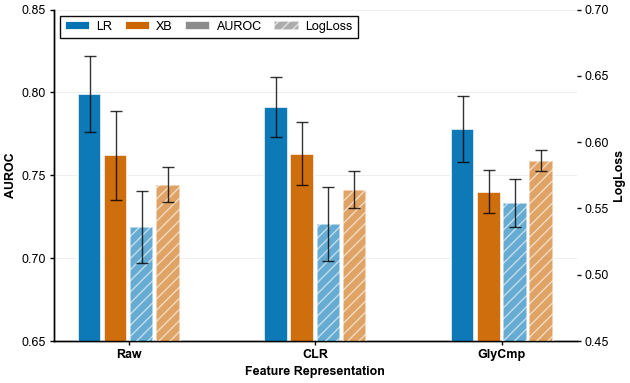

In [16]:
# Plot between-test-cohort metrics for out-of-cohort test set
AXIS_CONFIG_OVERALL = {
    "AUROC": {"primary": {"ylim": (0.65, 0.85), "yticks": np.linspace(0.65, 0.85, 5)}},
    "LogLoss": {"secondary": {"ylim": (0.45, 0.70), "yticks": np.linspace(0.45, 0.70, 6)}},
}

fig, ax1, ax2 = plot_between_test_cohort_metrics_overall(summary_all, 
                                                        model_names=(MODEL_KEYS[0], MODEL_KEYS[1]), 
                                                        preprocessor_names=[PROCESSOR_KEYS[0], PROCESSOR_KEYS[1], PROCESSOR_KEYS[2]], 
                                                        set_name='test_out', show_sem=True,
                                                        figsize=(6.5, 4),
                                                        metrics=list(AXIS_CONFIG_OVERALL.keys()),
                                                        axis_config=AXIS_CONFIG_OVERALL)
plt.tight_layout()
plt.subplots_adjust(right=0.90)  # Make room for the legend

_, _ = save_figure_aga_compliant(
    fig=fig,
    path=FIGURE_DIR,
    filename='figure 4',
    format='tiff',
    dpi=500
)

### Generalization gaps - In-sample vs. Out-of-sample

✓ CMYK TIFF created


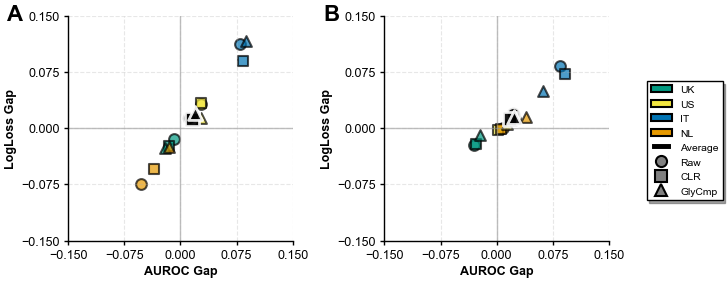

In [ ]:
# Overall performance summary
AXIS_CONFIG_OVERALL_GEN = {
    "AUROC": {"primary": {"xlim": (-0.15, 0.15), "xticks": np.linspace(-0.15, 0.15, 5)}},
    "LogLoss": {"secondary": {"ylim": (-0.15, 0.15), "yticks": np.linspace(-0.15, 0.15, 5)}},
}

METRICS = list(AXIS_CONFIG_OVERALL_GEN.keys())

GEN_SETS_TRAIN_VAL = ['train', 'val_in']
GEN_SETS_VAL_TEST = ['val_in', 'test_in']
GEN_SETS_TEST_TEST = ['test_in', 'test_out']

metrics_dicts, results_dicts, mode, metrics_dfs = run_full_generalization_gap_analysis_overall(
    results_loco_test_cohorts=results_loco_test_cohorts,
    metrics=METRICS,
    model_keys=MODEL_KEYS,  # e.g. ['LR', 'XB']
    sets=GEN_SETS_TEST_TEST,
    group_by="Preprocessor",
)

fig, axes = create_figure_with_panels(figsize=(6.5, 3), layout=(1, 2))

plot_generalization_gaps_overall(metrics_dicts[MODEL_KEYS[0]], 
                                 mode=mode, 
                                 as_fold_change=False, 
                                 cohort_palette=COHORT_COLORS, 
                                 ax=axes[0], 
                                 axis_config=AXIS_CONFIG_OVERALL_GEN, 
                                 sets=GEN_SETS_TEST_TEST)
plot_generalization_gaps_overall(metrics_dicts[MODEL_KEYS[1]], 
                                 mode=mode, 
                                 as_fold_change=False, 
                                 cohort_palette=COHORT_COLORS, 
                                 ax=axes[1], 
                                 axis_config=AXIS_CONFIG_OVERALL_GEN, 
                                 sets=GEN_SETS_TEST_TEST)

# Get legend info
legend = axes[0].get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.get_texts()]

# Remove both legends
axes[0].get_legend().remove()
axes[1].get_legend().remove()

# Create single-column vertical legend on the side
fig.legend(handles, labels,
          loc='center left',
          bbox_to_anchor=(1.0, 0.5),
          frameon=True,
          shadow=True,
          fontsize='small',
          ncol=1)  # Single column for vertical layout

plt.tight_layout()
plt.subplots_adjust(right=0.95)  # Make room for the legend

_, _ = save_figure_aga_compliant(
    fig=fig,
    path=FIGURE_DIR,
    filename='figure 3',
    format='tiff',
    dpi=500
)

### Generalization gaps - Training vs. In-sample (Validation)

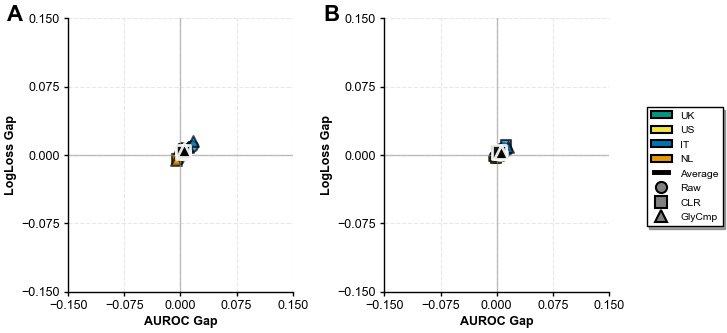

In [ ]:
metrics_dicts, results_dicts, mode, metrics_dfs = run_full_generalization_gap_analysis_overall(
    results_loco_test_cohorts=results_loco_test_cohorts,
    metrics=METRICS,
    model_keys=MODEL_KEYS,  # e.g. ['LR', 'XB']
    sets=GEN_SETS_VAL_TEST,
    group_by="Preprocessor",
)

fig, axes = create_figure_with_panels(figsize=(6.5, 3.5), layout=(1, 2))

plot_generalization_gaps_overall(metrics_dicts[MODEL_KEYS[0]], 
                                 mode=mode, 
                                 as_fold_change=False, 
                                 cohort_palette=COHORT_COLORS, 
                                 ax=axes[0], 
                                 axis_config=AXIS_CONFIG_OVERALL_GEN, sets=GEN_SETS_VAL_TEST)
plot_generalization_gaps_overall(metrics_dicts[MODEL_KEYS[1]], 
                                 mode=mode, 
                                 as_fold_change=False, 
                                 cohort_palette=COHORT_COLORS, 
                                 ax=axes[1], 
                                 axis_config=AXIS_CONFIG_OVERALL_GEN, sets=GEN_SETS_VAL_TEST)
# Get legend info
legend = axes[0].get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.get_texts()]

# Remove both legends
axes[0].get_legend().remove()
axes[1].get_legend().remove()

# Create single-column vertical legend on the side
fig.legend(handles, labels,
          loc='center left',
          bbox_to_anchor=(1.0, 0.5),
          frameon=True,
          shadow=True,
          fontsize='small',
          ncol=1)  # Single column for vertical layout

plt.tight_layout()
plt.subplots_adjust(right=0.95)  # Make room for the legend

# Subgroup analysis

### Out-of-sample performance

✓ CMYK TIFF created


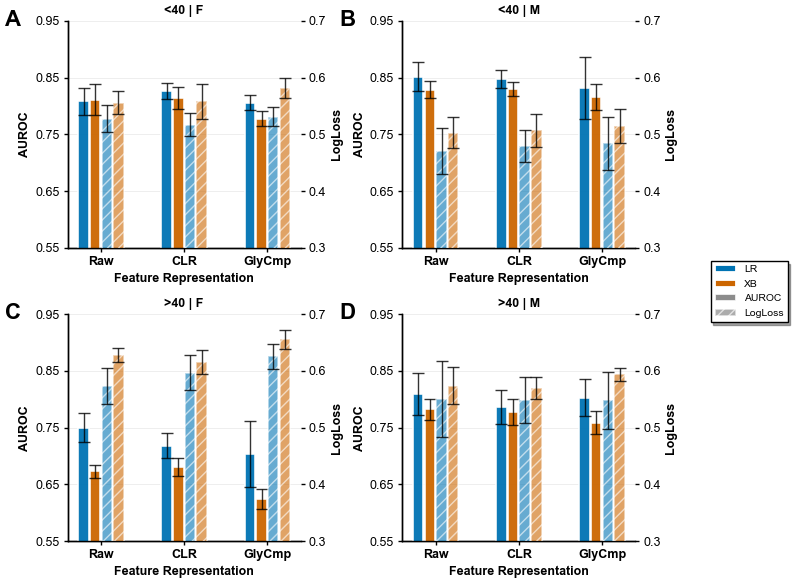

In [ ]:
# Subgroup performance summary
AXIS_CONFIG_SUBGROUP = {
    "AUROC": {"primary": {"ylim": (0.55, 0.95), "yticks": np.linspace(0.55, 0.95, 5)}},
    "LogLoss": {"secondary": {"ylim": (0.30, 0.70), "yticks": np.linspace(0.30, 0.70, 5)}},
}

METRICS = list(AXIS_CONFIG_SUBGROUP.keys())

fig, axes = create_figure_with_panels(figsize=(7, 6), layout=(2, 2))

plot_between_test_cohort_metrics_subgroup(summary_all, 
                                           model_names=(MODEL_KEYS[0], MODEL_KEYS[1]),
                                           preprocessor_names=[PROCESSOR_KEYS[0], PROCESSOR_KEYS[1], PROCESSOR_KEYS[2]], 
                                           set_name='test_out', 
                                           subgroup_var='age_sex', 
                                           metrics=METRICS,
                                           groups=['<40 | F'],
                                           show_sem=True, 
                                           ax=axes[0],
                                            axis_config=AXIS_CONFIG_SUBGROUP)
plot_between_test_cohort_metrics_subgroup(summary_all, 
                                           model_names=(MODEL_KEYS[0], MODEL_KEYS[1]),
                                           preprocessor_names=[PROCESSOR_KEYS[0], PROCESSOR_KEYS[1], PROCESSOR_KEYS[2]], 
                                           set_name='test_out', 
                                           subgroup_var='age_sex', 
                                           metrics=METRICS,
                                           groups=['<40 | M'], 
                                           show_sem=True, 
                                           ax=axes[1],
                                            axis_config=AXIS_CONFIG_SUBGROUP)
plot_between_test_cohort_metrics_subgroup(summary_all, 
                                           model_names=(MODEL_KEYS[0], MODEL_KEYS[1]),
                                            preprocessor_names=[PROCESSOR_KEYS[0], PROCESSOR_KEYS[1], PROCESSOR_KEYS[2]],
                                           set_name='test_out', 
                                           subgroup_var='age_sex', 
                                           metrics=METRICS,
                                           groups=['>40 | F'], 
                                           show_sem=True, 
                                           ax=axes[2],
                                            axis_config=AXIS_CONFIG_SUBGROUP)
plot_between_test_cohort_metrics_subgroup(summary_all, 
                                           model_names=(MODEL_KEYS[0], MODEL_KEYS[1]),
                                            preprocessor_names=[PROCESSOR_KEYS[0], PROCESSOR_KEYS[1], PROCESSOR_KEYS[2]],
                                           set_name='test_out', 
                                           subgroup_var='age_sex', 
                                           metrics=METRICS,
                                           groups=['>40 | M'], 
                                           show_sem=True, 
                                           ax=axes[3],
                                            axis_config=AXIS_CONFIG_SUBGROUP)

# Get legend info
legend = axes[0].get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.get_texts()]

# Remove both legends
axes[0].get_legend().remove()
axes[1].get_legend().remove()
axes[2].get_legend().remove()
axes[3].get_legend().remove()

# Create single-column vertical legend on the side
fig.legend(handles, labels,
          loc='center left',
          bbox_to_anchor=(1.0, 0.5),
          frameon=True,
          shadow=True,
          fontsize='small',
          ncol=1)  # Single column for vertical layout

plt.tight_layout()
plt.subplots_adjust(right=0.90)  # Make room for the legend

_, _ = save_figure_aga_compliant(
    fig=fig,
    path=FIGURE_DIR,
    filename='figure S3',
    format='tiff',
    dpi=500
)

### Generalization gaps - In-sample vs. Out-of-sample

✓ CMYK TIFF created


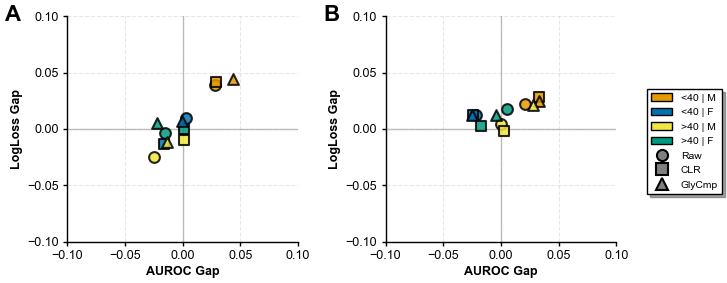

In [20]:
AXIS_CONFIG_SUBGROUP_GEN = {
    "AUROC": {"primary": {"xlim": (-0.10, 0.10), "xticks": np.linspace(-0.10, 0.10, 5)}},
    "LogLoss": {"secondary": {"ylim": (-0.10, 0.10), "yticks": np.linspace(-0.10, 0.10, 5)}},
}

results_dicts_subgroup, mode, df_m1, df_m2, subgroups_avail = (
    run_full_generalization_gap_analysis_subgroups(
        subgroup_analyses_loco_test_cohorts=subgroup_analyses_loco_test_cohorts,
        metrics=METRICS,          # e.g. ['AUROC', 'LogLoss']
        model_keys=MODEL_KEYS,    # e.g. ['LR', 'XB']
        sets=GEN_SETS_TEST_TEST,
    )
)


fig, axes = create_figure_with_panels(figsize=(6.5, 3), layout=(1, 2))

plot_generalization_gaps_subgroups(
    results_dicts_subgroup[MODEL_KEYS[0]],
    mode='preprocessing',
    as_fold_change=False,
    subgroup_palette=SUBGROUP_COLORS,
    ax=axes[0],
    axis_config=AXIS_CONFIG_SUBGROUP_GEN,
    sets=GEN_SETS_TEST_TEST
 )

plot_generalization_gaps_subgroups(
    results_dicts_subgroup[MODEL_KEYS[1]],
    mode='preprocessing',
    as_fold_change=False,
    subgroup_palette=SUBGROUP_COLORS,
    ax=axes[1],
    axis_config=AXIS_CONFIG_SUBGROUP_GEN,
    sets=GEN_SETS_TEST_TEST
 )

# Get legend info
legend = axes[0].get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.get_texts()]

# Remove both legends
axes[0].get_legend().remove()
axes[1].get_legend().remove()

# Create single-column vertical legend on the side
fig.legend(handles, labels,
          loc='center left',
          bbox_to_anchor=(1.0, 0.5),
          frameon=True,
          shadow=True,
          fontsize='small',
          ncol=1)  # Single column for vertical layout

plt.tight_layout()
plt.subplots_adjust(right=0.95)  # Make room for the legend


plt.tight_layout()

_, _ = save_figure_aga_compliant(
    fig=fig,
    path=FIGURE_DIR,
    filename='figure 5',
    format='tiff',
    dpi=500
)